# Treino de Rede LSTM com Dados de Ângulos Articulares
## Classificação de Exercícios com Janelas Temporais (Window=15, Stride=1)

Este notebook implementa uma LSTM para classificação de 4 exercícios (flexão, agachamento, descanso, rosca_bíceps) usando janelas temporais de ângulos articulares extraídos com MediaPipe.

### Garantias anti-vazamento (mesmo protocolo do Random Forest):
- **`video_source` propagado**: cada frame carrega a origem do CSV, evitando colisão de IDs entre vídeos
- **Windowing por grupo**: janelas criadas dentro de cada `(video_source, exercise)` — nunca cruzam fronteiras de vídeo
- **Stride=1**: sobreposição total — maximiza amostras de treino
- **Split manual por sujeito**: vídeos inteiros vão para treino **ou** para teste — o mesmo sujeito nunca aparece nos dois splits
- **Scaler fitado apenas no treino**: `StandardScaler` ajustado somente nos dados de treino, sem vazamento de estatísticas do teste
- **Undersampling balanceado**: igual número de janelas por classe em cada split

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization,
    Bidirectional, Conv1D,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score,
)
from sklearn.model_selection import LeaveOneGroupOut

from utils.calculador_angulos import calculate_angle, extract_angles_from_landmarks

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Bibliotecas importadas com sucesso")
print(f"  TensorFlow: {tf.__version__}")


✓ Bibliotecas importadas com sucesso
  TensorFlow: 2.21.0


## 1. Carregar e Explorar os Dados

Os dados são divididos **manualmente por sujeito** para garantir que o modelo seja avaliado em uma pessoa nunca vista durante o treino:

- **Treino**: Rafael, Paulo, Letícia
- **Teste**: Rodrigo (sujeito completamente novo)

In [30]:
# Configurações
OUTPUT_DIR = Path("files_brutos")
ML_MODELS_DIR = Path("ml_models")
ML_MODELS_DIR.mkdir(exist_ok=True)

# ── Divisão manual por sujeito ───────────────────────────────────────────────
# TREINO: rafael + paulo + leticia
# TESTE:  rodrigo (sujeito nunca visto no treino)

TRAIN_FILES = [
    "rafael_rosca_biceps_video_compilado_15_05_202_full_5fps_rosca_biceps.csv",
    "rafael_flexao_video_compilado_15_05_2025_full_5fps_flexao.csv",
    "rafael_descanso_video_compilado_15_05_2025_full_5fps_descanso.csv",
    "rafael_agachamento_video_compilado_15_05_2025_full_5fps_agachamento.csv",

    "paulo_2_min_rosca_direta_full_5fps_rosca_biceps_paulo.csv",
    "paulo_2_min_flexao_full_5fps_flexao_paulo.csv",
    "paulo_2_min_agachamento_full_5fps_agachamento_paulo.csv",

    "leticia_flexao720p_full_5fps_flexao.csv",
    "leticia_Descanso720p (3)_full_5fps_descanso.csv",
    "leticia_biceps720p_full_5fps_rosca_biceps.csv",
    "leticia_agachamento720p_full_5fps_agachamento.csv",

]

TEST_FILES = [
    "1 - rodrigo_descanso_consolidado_full_5fps_descanso.csv",
    "1 - flexao_full_5fps_flexao.csv",
    "1 - rodrigo_agachamento2.csv",
    "1 - rodrigo_roscadireta2.csv",


]


def load_files(file_list, split_tag):
    dfs = []
    for csv_file in file_list:
        csv_path = OUTPUT_DIR / csv_file
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df['video_source'] = csv_file
            df['split'] = split_tag
            print(f"  ✓ {csv_file}  →  {df['exercise'].unique()[0]}")
            dfs.append(df)
        else:
            print(f"  ✗ NÃO ENCONTRADO: {csv_file}")
    return pd.concat(dfs, axis=0, ignore_index=True)


print("📂 Carregando arquivos de TREINO (rafael + paulo + leticia):")
data_raw_train = load_files(TRAIN_FILES, 'train')

print(f"\n📂 Carregando arquivos de TESTE (rodrigo):")
data_raw_test = load_files(TEST_FILES, 'test')

data_raw = pd.concat([data_raw_train, data_raw_test], axis=0, ignore_index=True)
print(f"\n📊 Total: {data_raw.shape[0]} linhas  |  {data_raw['video_source'].nunique()} vídeos")
print(f"   Treino: {len(data_raw_train):>6} linhas  ({data_raw_train['video_source'].nunique()} vídeos)")
print(f"   Teste:  {len(data_raw_test):>6} linhas  ({data_raw_test['video_source'].nunique()} vídeos)")

📂 Carregando arquivos de TREINO (rafael + paulo + leticia):
  ✓ rafael_rosca_biceps_video_compilado_15_05_202_full_5fps_rosca_biceps.csv  →  rosca_biceps
  ✓ rafael_flexao_video_compilado_15_05_2025_full_5fps_flexao.csv  →  flexao
  ✓ rafael_descanso_video_compilado_15_05_2025_full_5fps_descanso.csv  →  descanso
  ✓ rafael_agachamento_video_compilado_15_05_2025_full_5fps_agachamento.csv  →  agachamento
  ✓ paulo_2_min_rosca_direta_full_5fps_rosca_biceps_paulo.csv  →  rosca_biceps
  ✓ paulo_2_min_flexao_full_5fps_flexao_paulo.csv  →  flexao
  ✓ paulo_2_min_agachamento_full_5fps_agachamento_paulo.csv  →  agachamento
  ✓ leticia_flexao720p_full_5fps_flexao.csv  →  flexao
  ✓ leticia_Descanso720p (3)_full_5fps_descanso.csv  →  descanso
  ✓ leticia_biceps720p_full_5fps_rosca_biceps.csv  →  rosca_biceps
  ✓ leticia_agachamento720p_full_5fps_agachamento.csv  →  agachamento

📂 Carregando arquivos de TESTE (rodrigo):
  ✓ 1 - rodrigo_descanso_consolidado_full_5fps_descanso.csv  →  descanso
  ✓ 1

In [31]:
# Extrair ângulos articulares dos landmarks do MediaPipe
# A função 'extract_angles_from_landmarks' calcula ângulos de cotovelo, ombro,
# joelho e quadril para cada frame, usando as coordenadas dos landmarks 3D.
# O campo 'video_source' é propagado automaticamente para cada frame.
print("Extraindo ângulos dos landmarks...")
data = extract_angles_from_landmarks(data_raw)

# Reatribuir coluna 'split' via video_source (cada vídeo tem um único split)
split_map = data_raw.drop_duplicates('video_source').set_index('video_source')['split']
data['split'] = data['video_source'].map(split_map)

print(f"✓ Ângulos extraídos: {data.shape[0]} frames, {data.shape[1]} colunas")
print(f"\n📊 Distribuição por exercício:")
print(data['exercise'].value_counts())
print(f"\n📹 Frames por vídeo (split):")
for vs, grp in data.groupby('video_source'):
    print(f"  [{grp['split'].iloc[0]:5}] {vs}: {len(grp)} frames")

Extraindo ângulos dos landmarks...
✓ Ângulos extraídos: 14435 frames, 21 colunas

📊 Distribuição por exercício:
exercise
descanso        4300
rosca_biceps    3751
agachamento     3582
flexao          2802
Name: count, dtype: int64

📹 Frames por vídeo (split):
  [test ] 1 - flexao_full_5fps_flexao.csv: 511 frames
  [test ] 1 - rodrigo_agachamento2.csv: 712 frames
  [test ] 1 - rodrigo_descanso_consolidado_full_5fps_descanso.csv: 1694 frames
  [test ] 1 - rodrigo_roscadireta2.csv: 671 frames
  [train] leticia_Descanso720p (3)_full_5fps_descanso.csv: 866 frames
  [train] leticia_agachamento720p_full_5fps_agachamento.csv: 784 frames
  [train] leticia_biceps720p_full_5fps_rosca_biceps.csv: 630 frames
  [train] leticia_flexao720p_full_5fps_flexao.csv: 589 frames
  [train] paulo_2_min_agachamento_full_5fps_agachamento_paulo.csv: 499 frames
  [train] paulo_2_min_flexao_full_5fps_flexao_paulo.csv: 509 frames
  [train] paulo_2_min_rosca_direta_full_5fps_rosca_biceps_paulo.csv: 691 frames
  [trai

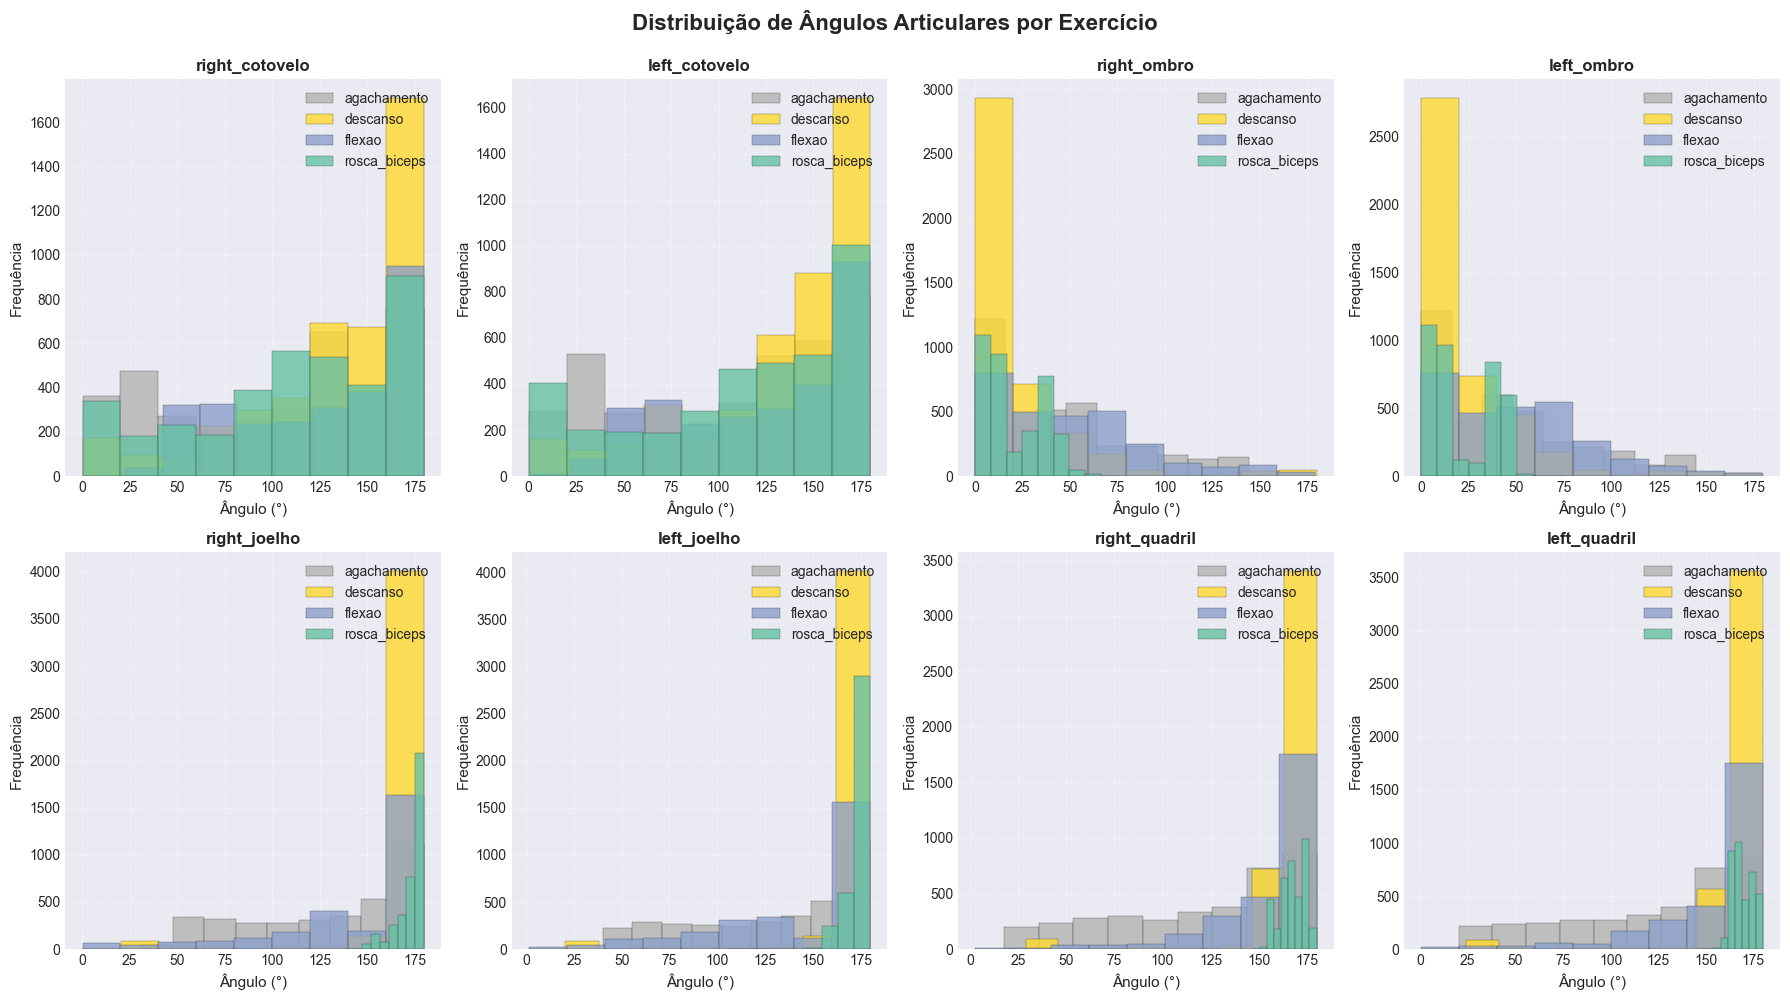

In [32]:
# Visualizar distribuições dos ângulos por exercício
# Isso ajuda a entender quais articulações são mais discriminativas entre as classes
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

colors = plt.cm.Set2(np.linspace(0, 1, len(data['exercise'].unique())))
exercise_colors = {ex: colors[i] for i, ex in enumerate(data['exercise'].unique())}

angle_columns = ['right_cotovelo', 'left_cotovelo', 'right_ombro', 'left_ombro',
                 'right_joelho', 'left_joelho', 'right_quadril', 'left_quadril']

for idx, col in enumerate(angle_columns):
    for exercise in sorted(data['exercise'].unique()):
        subset = data[data['exercise'] == exercise][col]
        axes[idx].hist(subset, alpha=0.8, label=exercise, bins=9,
                       color=exercise_colors[exercise], edgecolor='black', linewidth=0.2)
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Ângulo (°)', fontsize=11)
    axes[idx].set_ylabel('Frequência', fontsize=11)
    axes[idx].legend(fontsize=10, loc='upper right', framealpha=0.95)
    axes[idx].grid(alpha=0.4, linestyle='--')

plt.suptitle('Distribuição de Ângulos Articulares por Exercício', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 2. Criação de Janelas Temporais com Features de Tempo

### Estrutura do input LSTM — 1 frame por timestep:
A LSTM recebe tensores 3D `(n_amostras, timesteps, features)` onde **cada timestep = 1 frame**.  
Isso é diferente do Random Forest, que achata a janela inteira em um único vetor.

```
Input shape: (n_amostras, 15 frames, 10 features)
                                      └── 8 ângulos + 2 features temporais
```

### Features temporais adicionadas a cada frame:
| Feature | Descrição | Exemplo |
|---|---|---|
| `frame_norm` | Posição do frame dentro do vídeo, normalizada [0, 1] | 0.0 = início, 1.0 = final |
| `time_sec` | Tempo em segundos desde o início do vídeo (frame / 5 fps) | 0.0 s, 0.2 s, 0.4 s... |

Essas features dão à LSTM **contexto temporal global** — ela pode aprender que certos padrões angulares ocorrem mais no início vs. final de um exercício.

### Garantias anti-vazamento (inalteradas):
- Agrupamento por `(video_source, exercise)` — nenhuma janela cruza fronteiras de vídeo
- Stride=1, split manual por sujeito

In [44]:
def create_temporal_windows_3d(df, window_size=15, stride=1, angle_columns=None, fps=5.0):
    """
    Cria janelas temporais 3D para LSTM — 1 frame por timestep.

    Input shape retornado: (n_janelas, window_size, n_features)

    Features por timestep (frame):
        - 8 ângulos articulares (cotovelo, ombro, joelho, quadril)
        - 8 velocidades angulares (Δângulo: frame[t] - frame[t-1])
              → captura dinâmica do movimento — fundamental para distinguir
                agachamento/flexão que têm posturas similares mas dinâmicas distintas
        - 4 assimetrias L/R (right_angle - left_angle por articulação)
              → cada exercício tem padrão assimétrico característico
        - frame_norm : posição do frame no vídeo, normalizada [0, 1]
        - time_sec   : tempo em segundos desde o início do vídeo (frame_pos / fps)

    Total: 8 + 8 + 4 + 2 = 22 features por timestep

    A estrutura 3D preserva a ordem temporal explicitamente — diferente do
    Random Forest que achata a janela inteira em um único vetor de 120 features.
    """
    if angle_columns is None:
        angle_columns = [
            'right_cotovelo', 'left_cotovelo', 'right_ombro', 'left_ombro',
            'right_joelho', 'left_joelho', 'right_quadril', 'left_quadril'
        ]

    # Pares de articulações para cálculo de assimetria (right - left)
    joint_pairs = [
        ('right_cotovelo', 'left_cotovelo'),
        ('right_ombro',    'left_ombro'),
        ('right_joelho',   'left_joelho'),
        ('right_quadril',  'left_quadril'),
    ]
    pair_r_idx = [angle_columns.index(r) for r, _ in joint_pairs]
    pair_l_idx = [angle_columns.index(l) for _, l in joint_pairs]

    X_list, labels_list, meta_list = [], [], []

    for (video_source, exercise), group in df.groupby(['video_source', 'exercise'], sort=False):
        group = group.sort_values('frame').reset_index(drop=True)
        n = len(group)
        split_tag = group['split'].iloc[0]

        for i in range(0, n - window_size + 1, stride):
            # ── Ângulos (window_size × 8) ──────────────────────────────────
            window_angles = group.iloc[i:i + window_size][angle_columns].values.astype(np.float32)

            # ── Velocidade angular: Δângulo frame-a-frame (window_size × 8) ─
            # Para o 1º frame da janela, velocidade = 0 (sem histórico anterior)
            velocity = np.zeros_like(window_angles)
            velocity[1:] = window_angles[1:] - window_angles[:-1]

            # ── Assimetria L/R por articulação (window_size × 4) ───────────
            # right_angle - left_angle: cada exercício tem padrão assimétrico
            asymmetry = (window_angles[:, pair_r_idx] - window_angles[:, pair_l_idx])  # (window_size, 4)

            # ── Features temporais (window_size × 2) ───────────────────────
            frame_positions = np.arange(i, i + window_size, dtype=np.float32)
            frame_norm = frame_positions / max(n - 1, 1)
            time_sec   = frame_positions / fps
            time_feats = np.stack([frame_norm, time_sec], axis=1)   # (window_size, 2)

            # ── Concatenar: 8 + 8 + 4 + 2 = 22 features por timestep ───────
            window_data = np.concatenate(
                [window_angles, velocity, asymmetry, time_feats], axis=1
            )  # (window_size, 22)

            X_list.append(window_data)
            labels_list.append(exercise)
            meta_list.append({'video_source': video_source, 'split': split_tag})

    X = np.array(X_list)           # (n_janelas, window_size, 22)
    y = pd.Series(labels_list, name='exercise')
    meta = pd.DataFrame(meta_list)

    n_angles   = len(angle_columns)
    n_velocity = n_angles
    n_asym     = len(joint_pairs)
    n_temporal = 2
    n_total    = n_angles + n_velocity + n_asym + n_temporal

    print(f"✓ Janelas 3D criadas: {X.shape[0]} amostras")
    print(f"  Shape: {X.shape}  (amostras × timesteps × features)")
    print(f"  Features por timestep: {n_angles} ângulos  +  {n_velocity} velocidades  "
          f"+  {n_asym} assimetrias  +  {n_temporal} temporais  =  {n_total}")
    print(f"  Stride: {stride}  ({'sobreposição total' if stride == 1 else f'janelas compartilham {window_size - stride}/{window_size} frames'})")
    for tag in ['train', 'test']:
        cnt = (meta['split'] == tag).sum()
        print(f"  {tag.upper():5}: {cnt} janelas")

    return X, y, meta


angle_columns = ['right_cotovelo', 'left_cotovelo', 'right_ombro', 'left_ombro',
                 'right_joelho', 'left_joelho', 'right_quadril', 'left_quadril']

print("Criando janelas 3D com features de ângulo, velocidade, assimetria e tempo...")
print("  (window=15, stride=1, fps=5)\n")
X, y, meta = create_temporal_windows_3d(data, window_size=15, stride=1,
                                         angle_columns=angle_columns, fps=5.0)
print(f"\nShape de X: {X.shape}")
print(f"  → {X.shape[0]} janelas × {X.shape[1]} frames × {X.shape[2]} features por frame")
print(f"     (8 ângulos + 8 velocidades + 4 assimetrias + 2 temporais)")
print(f"\nDistribuição de classes:")
print(y.value_counts())


Criando janelas 3D com features de ângulo, velocidade, assimetria e tempo...
  (window=15, stride=1, fps=5)

✓ Janelas 3D criadas: 14225 amostras
  Shape: (14225, 15, 22)  (amostras × timesteps × features)
  Features por timestep: 8 ângulos  +  8 velocidades  +  4 assimetrias  +  2 temporais  =  22
  Stride: 1  (sobreposição total)
  TRAIN: 10693 janelas
  TEST : 3532 janelas

Shape de X: (14225, 15, 22)
  → 14225 janelas × 15 frames × 22 features por frame
     (8 ângulos + 8 velocidades + 4 assimetrias + 2 temporais)

Distribuição de classes:
exercise
descanso        4258
rosca_biceps    3695
agachamento     3526
flexao          2746
Name: count, dtype: int64


In [45]:
# Codificar labels — 4 classes (mesmo mapeamento do Random Forest para comparabilidade)
label_map = {
    'flexao':       0,
    'agachamento':  1,
    'descanso':     2,
    'rosca_biceps': 3,
}
reverse_label_map = {v: k for k, v in label_map.items()}

y_encoded = y.map(label_map)
groups = meta['video_source']

# ── Split manual por sujeito ─────────────────────────────────────────────────
# Treino = rafael + paulo + leticia  |  Teste = rodrigo
# Cada vídeo inteiro vai para apenas um split — zero contaminação entre treino e teste
train_mask = meta['split'] == 'train'
test_mask  = meta['split'] == 'test'

X_train = X[train_mask.values]
X_test  = X[test_mask.values]
y_train = y_encoded[train_mask].reset_index(drop=True)
y_test  = y_encoded[test_mask].reset_index(drop=True)
groups_train = groups[train_mask].reset_index(drop=True)
groups_test  = groups[test_mask].reset_index(drop=True)

print("✓ Labels codificados (4 classes):")
for exercise, label in label_map.items():
    n_tr = (y_train == label).sum()
    n_te = (y_test  == label).sum()
    print(f"  {exercise:15} ({label}): treino={n_tr:5d}  teste={n_te:5d}")

print(f"\n✓ Split por sujeito (sem vazamento):")
print(f"  Treino: {len(X_train):5d} janelas  — {sorted(groups_train.unique().tolist())}")
print(f"  Teste:  {len(X_test):5d} janelas  — {sorted(groups_test.unique().tolist())}")

✓ Labels codificados (4 classes):
  flexao          (0): treino= 2249  teste=  497
  agachamento     (1): treino= 2828  teste=  698
  descanso        (2): treino= 2578  teste= 1680
  rosca_biceps    (3): treino= 3038  teste=  657

✓ Split por sujeito (sem vazamento):
  Treino: 10693 janelas  — ['leticia_Descanso720p (3)_full_5fps_descanso.csv', 'leticia_agachamento720p_full_5fps_agachamento.csv', 'leticia_biceps720p_full_5fps_rosca_biceps.csv', 'leticia_flexao720p_full_5fps_flexao.csv', 'paulo_2_min_agachamento_full_5fps_agachamento_paulo.csv', 'paulo_2_min_flexao_full_5fps_flexao_paulo.csv', 'paulo_2_min_rosca_direta_full_5fps_rosca_biceps_paulo.csv', 'rafael_agachamento_video_compilado_15_05_2025_full_5fps_agachamento.csv', 'rafael_descanso_video_compilado_15_05_2025_full_5fps_descanso.csv', 'rafael_flexao_video_compilado_15_05_2025_full_5fps_flexao.csv', 'rafael_rosca_biceps_video_compilado_15_05_202_full_5fps_rosca_biceps.csv']
  Teste:   3532 janelas  — ['1 - flexao_full_5fps_flex

In [46]:
# ── Balanceamento por undersampling (treino e teste separadamente) ────────────
# Garante igual número de janelas por classe em cada split, sem cruzar fronteiras.
# O undersampling é feito ANTES da normalização — sobre os dados brutos — para
# evitar que as estatísticas do scaler sejam afetadas pela distribuição das classes.

rng = np.random.RandomState(42)


def undersample_balanced(X_split, y_split, groups_split, label_map, rng):
    """Undersample cada classe para o mínimo encontrado no split."""
    min_count = y_split.value_counts().min()
    parts_X, parts_y, parts_g = [], [], []
    for label in sorted(label_map.values()):
        mask = y_split == label
        if mask.sum() == 0:
            continue
        idx = np.where(mask)[0]
        chosen = rng.choice(idx, size=min_count, replace=False)
        parts_X.append(X_split[chosen])
        parts_y.append(y_split.iloc[chosen])
        parts_g.append(groups_split.iloc[chosen])
    X_bal = np.concatenate(parts_X, axis=0)
    y_bal = pd.concat(parts_y).reset_index(drop=True)
    g_bal = pd.concat(parts_g).reset_index(drop=True)
    return X_bal, y_bal, g_bal


X_train, y_train, groups_train = undersample_balanced(X_train, y_train, groups_train, label_map, rng)
X_test,  y_test,  groups_test  = undersample_balanced(X_test,  y_test,  groups_test,  label_map, rng)

print("✓ Classes balanceadas por undersampling (min por classe em cada split):")
print(f"\n  Treino ({len(X_train)} janelas):")
for label, exercise in sorted([(v, k) for k, v in label_map.items()]):
    n = (y_train == label).sum()
    if n > 0:
        print(f"    {exercise:15}: {n:5d}")

print(f"\n  Teste ({len(X_test)} janelas):")
for label, exercise in sorted([(v, k) for k, v in label_map.items()]):
    n = (y_test == label).sum()
    if n > 0:
        print(f"    {exercise:15}: {n:5d}")

✓ Classes balanceadas por undersampling (min por classe em cada split):

  Treino (8996 janelas):
    flexao         :  2249
    agachamento    :  2249
    descanso       :  2249
    rosca_biceps   :  2249

  Teste (1988 janelas):
    flexao         :   497
    agachamento    :   497
    descanso       :   497
    rosca_biceps   :   497


## 3. Normalização das Features

O `StandardScaler` é **fitado apenas no conjunto de treino** e depois aplicado ao teste.

Para dados 3D `(n_amostras, 15_frames, 8_ângulos)`, a estratégia é:
1. Reshape para 2D: `(n_amostras × 15, 8)`
2. `fit_transform` no treino / `transform` no teste
3. Reshape de volta para 3D: `(n_amostras, 15, 8)`

Isso garante que a média e o desvio padrão de cada ângulo são calculados **somente a partir dos dados de treino**, sem nenhum vazamento de informação do conjunto de teste.

In [47]:
# ── Normalização sem vazamento: fit apenas no treino ─────────────────────────
# X shape: (n_amostras, window_size=15, n_angles=8)
# Estratégia: reshape para 2D → fit/transform → reshape de volta para 3D

n_train, window_size, n_features = X_train.shape
n_test = X_test.shape[0]
n_classes = len(label_map)

scaler = StandardScaler()

# Reshape: (n_amostras, 15, 8) → (n_amostras * 15, 8)
X_train_2d = X_train.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

# Scaler FITADO SOMENTE NO TREINO — o teste apenas é transformado
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d  = scaler.transform(X_test_2d)   # apenas transform!

# Restaurar shape 3D para a LSTM
X_train_scaled = X_train_scaled_2d.reshape(n_train, window_size, n_features)
X_test_scaled  = X_test_scaled_2d.reshape(n_test,  window_size, n_features)

# Converter labels para one-hot encoding (necessário para softmax + categorical_crossentropy)
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat  = to_categorical(y_test,  num_classes=n_classes)

print("✓ Dados normalizados (scaler fitado apenas no treino):")
print(f"  X_train_scaled: {X_train_scaled.shape}  → input da LSTM")
print(f"  X_test_scaled:  {X_test_scaled.shape}")
print(f"\n✓ Labels em one-hot ({n_classes} classes):")
print(f"  y_train_cat: {y_train_cat.shape}")
print(f"  y_test_cat:  {y_test_cat.shape}")
print(f"\n  Mapeamento: {label_map}")

✓ Dados normalizados (scaler fitado apenas no treino):
  X_train_scaled: (8996, 15, 22)  → input da LSTM
  X_test_scaled:  (1988, 15, 22)

✓ Labels em one-hot (4 classes):
  y_train_cat: (8996, 4)
  y_test_cat:  (1988, 4)

  Mapeamento: {'flexao': 0, 'agachamento': 1, 'descanso': 2, 'rosca_biceps': 3}


## 3b. Cross-Validação por Vídeo — Leave-One-Subject-Out

Para avaliar a **generalização entre sujeitos**, aplicamos **Leave-One-Subject-Out Cross-Validation** com **todos os dados disponíveis** (Rafael, Paulo, Letícia e Rodrigo).

### Protocolo — 4 folds:
| Fold | Treino | Teste |
|---|---|---|
| 1 | Paulo + Letícia + Rodrigo | Rafael |
| 2 | Rafael + Letícia + Rodrigo | Paulo |
| 3 | Rafael + Paulo + Rodrigo | Letícia |
| 4 | Rafael + Paulo + Letícia | Rodrigo |

Cada fold **treina um modelo do zero** com a mesma arquitetura (Conv1D + Bidirectional LSTM).  
O split da seção 4 (treino = Rafael/Paulo/Letícia, teste = Rodrigo) é apenas uma das 4 partições avaliadas aqui.

Os resultados desta etapa **não influenciam** os pesos do modelo final treinado na seção 4.


🔄 Cross-Validação Leave-One-Subject-Out  (4 sujeitos = 4 folds)
   Sujeitos: ['leticia', 'paulo', 'rafael', 'rodrigo']

  Fold 1/4  (held-out: leticia )  n_treino=8684  n_teste=2300  →  acc=0.4326  f1=0.4234
  Fold 2/4  (held-out: paulo   )  n_treino=9004  n_teste=1455  →  acc=1.0000  f1=1.0000
  Fold 3/4  (held-out: rafael  )  n_treino=6268  n_teste=4716  →  acc=0.4998  f1=0.4732
  Fold 4/4  (held-out: rodrigo )  n_treino=8996  n_teste=1988  →  acc=0.6836  f1=0.6792

  RESUMO — Cross-Validação Leave-One-Subject-Out (todos os sujeitos)
 fold sujeito_teste  n_treino  n_teste  accuracy  f1_weighted
    1       leticia      8684     2300  0.432609     0.423422
    2         paulo      9004     1455  1.000000     1.000000
    3        rafael      6268     4716  0.499788     0.473159
    4       rodrigo      8996     1988  0.683602     0.679185

  Acurácia  média : 0.6540  ±  0.2539
  F1 ponderado    : 0.6439  ±  0.2619

💡 Modelo final (seção 4) usa treino=Rafael/Paulo/Letícia, teste=Rodrig

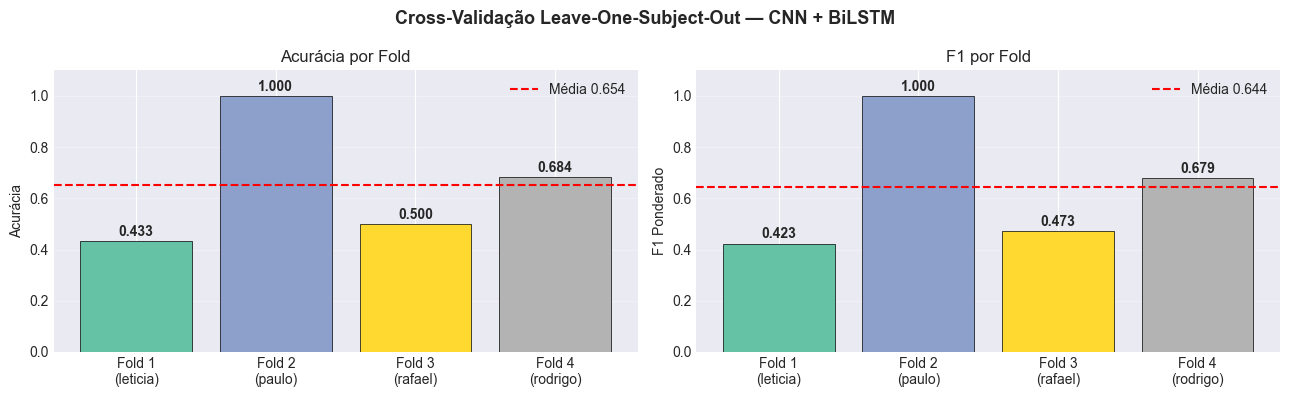

In [50]:
def get_subject(row):
    """Mapeia cada linha do meta para o sujeito correspondente.

    Usa o nome do arquivo CSV para identificar o sujeito.
    Fallback: arquivos do split 'test' sem nome reconhecível são do Rodrigo
    (ex: '1 - flexao_full_5fps_flexao.csv' não contém 'rodrigo' no nome).
    """
    vs = str(row['video_source']).lower()
    for name in ['rafael', 'paulo', 'leticia', 'rodrigo']:
        if name in vs:
            return name
    # Fallback: todos os arquivos de teste são do Rodrigo
    if row['split'] == 'test':
        return 'rodrigo'
    return 'unknown'


def build_fold_model(input_shape, n_cls):
    """Constrói um modelo CNN+BiLSTM com a mesma arquitetura do modelo final."""
    m = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
        Dropout(0.2),
        Bidirectional(LSTM(64, activation='tanh', return_sequences=True)),
        Dropout(0.3),
        LSTM(32, activation='tanh', return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(n_cls, activation='softmax'),
    ])
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m


# ── Todos os dados (treino + teste) para o cross-val ────────────────────────
subject_groups = meta.apply(get_subject, axis=1).values
unique_subjects = sorted(set(subject_groups))
logo = LeaveOneGroupOut()
n_folds = len(unique_subjects)

print(f"🔄 Cross-Validação Leave-One-Subject-Out  ({n_folds} sujeitos = {n_folds} folds)")
print(f"   Sujeitos: {unique_subjects}\n")

cv_results = []
rng_cv = np.random.RandomState(42)
callbacks_cv = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5, verbose=0),
]

for fold_idx, (tr_idx, te_idx) in enumerate(logo.split(X, y_encoded, subject_groups)):
    held_out = subject_groups[te_idx[0]]

    X_f_tr  = X[tr_idx]
    X_f_te  = X[te_idx]
    y_f_tr  = y_encoded.iloc[tr_idx].reset_index(drop=True)
    y_f_te  = y_encoded.iloc[te_idx].reset_index(drop=True)
    g_f_tr  = meta['video_source'].iloc[tr_idx].reset_index(drop=True)
    g_f_te  = meta['video_source'].iloc[te_idx].reset_index(drop=True)

    # Balancear cada fold
    X_f_tr_b, y_f_tr_b, _ = undersample_balanced(X_f_tr, y_f_tr, g_f_tr, label_map, rng_cv)
    X_f_te_b, y_f_te_b, _ = undersample_balanced(X_f_te, y_f_te, g_f_te, label_map, rng_cv)

    # Normalizar (scaler fitado apenas no treino do fold)
    n_tr_f, ws_f, nf_f = X_f_tr_b.shape
    n_te_f = X_f_te_b.shape[0]
    sc_f = StandardScaler()
    X_tr_s = sc_f.fit_transform(X_f_tr_b.reshape(-1, nf_f)).reshape(n_tr_f, ws_f, nf_f)
    X_te_s = sc_f.transform(X_f_te_b.reshape(-1, nf_f)).reshape(n_te_f, ws_f, nf_f)

    y_tr_cat_f = to_categorical(y_f_tr_b, n_classes)
    y_te_cat_f = to_categorical(y_f_te_b, n_classes)

    # Treinar modelo do fold
    keras.backend.clear_session()
    model_f = build_fold_model((ws_f, nf_f), n_classes)
    model_f.fit(
        X_tr_s, y_tr_cat_f,
        validation_data=(X_te_s, y_te_cat_f),
        epochs=80, batch_size=32,
        callbacks=callbacks_cv,
        verbose=0,
    )

    y_pred_f = model_f.predict(X_te_s, verbose=0).argmax(axis=1)
    fold_acc = accuracy_score(y_f_te_b, y_pred_f)
    fold_f1  = f1_score(y_f_te_b, y_pred_f, average='weighted')

    cv_results.append({
        'fold': fold_idx + 1,
        'sujeito_teste': held_out,
        'n_treino': n_tr_f,
        'n_teste': n_te_f,
        'accuracy': fold_acc,
        'f1_weighted': fold_f1,
    })

    print(f"  Fold {fold_idx + 1}/{n_folds}  (held-out: {held_out:8s})"
          f"  n_treino={n_tr_f}  n_teste={n_te_f}"
          f"  →  acc={fold_acc:.4f}  f1={fold_f1:.4f}")

    del model_f

# ── Reconstruir sessão limpa para o modelo final (seção 4) ──────────────────
keras.backend.clear_session()

cv_df = pd.DataFrame(cv_results)

print(f"\n{'='*68}")
print("  RESUMO — Cross-Validação Leave-One-Subject-Out (todos os sujeitos)")
print(f"{'='*68}")
print(cv_df[['fold', 'sujeito_teste', 'n_treino', 'n_teste', 'accuracy', 'f1_weighted']].to_string(index=False))
print(f"\n  Acurácia  média : {cv_df['accuracy'].mean():.4f}  ±  {cv_df['accuracy'].std():.4f}")
print(f"  F1 ponderado    : {cv_df['f1_weighted'].mean():.4f}  ±  {cv_df['f1_weighted'].std():.4f}")
print(f"\n💡 Modelo final (seção 4) usa treino=Rafael/Paulo/Letícia, teste=Rodrigo (fold 4 do CV).")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Cross-Validação Leave-One-Subject-Out — CNN + BiLSTM', fontsize=13, fontweight='bold')

bar_colors = plt.cm.Set2(np.linspace(0, 1, n_folds))
x_pos = np.arange(n_folds)
fold_labels = [f"Fold {r['fold']}\n({r['sujeito_teste']})" for _, r in cv_df.iterrows()]

axes[0].bar(x_pos, cv_df['accuracy'], color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0].axhline(cv_df['accuracy'].mean(), color='red', linestyle='--', label=f"Média {cv_df['accuracy'].mean():.3f}")
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(fold_labels)
axes[0].set_ylim([0, 1.1]); axes[0].set_ylabel('Acurácia')
axes[0].set_title('Acurácia por Fold'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(cv_df['accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(x_pos, cv_df['f1_weighted'], color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1].axhline(cv_df['f1_weighted'].mean(), color='red', linestyle='--', label=f"Média {cv_df['f1_weighted'].mean():.3f}")
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(fold_labels)
axes[1].set_ylim([0, 1.1]); axes[1].set_ylabel('F1 Ponderado')
axes[1].set_title('F1 por Fold'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(cv_df['f1_weighted']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Arquitetura da Rede LSTM

### Design:
- **LSTM(64, return_sequences=True)**: primeira camada — processa a sequência de 15 frames e passa os estados ocultos para a próxima camada LSTM
- **LSTM(32, return_sequences=False)**: segunda camada — consolida toda a sequência em um vetor de representação
- **BatchNormalization**: estabiliza o gradiente e acelera a convergência
- **Dropout**: regularização para reduzir overfitting
- **Dense(4, softmax)**: saída com probabilidades para as 4 classes

### Por que LSTM e não apenas Dense?
A LSTM captura **dependências temporais** entre frames: ela aprende que a *sequência de movimentos* (não apenas ângulos isolados) é o que define cada exercício.  
O Random Forest trata os 15 frames como 120 features independentes — a LSTM mantém a ordem temporal explicitamente com memória de curto e longo prazo.

In [37]:
# Construir modelo CNN + Bidirectional LSTM
# Input shape: (window_size=15, n_features=22)
#
# Arquitetura melhorada:
#   1. Conv1D(64, kernel=3): extrai padrões locais em janelas de 3 frames consecutivos
#      → detecta "micro-movimentos" antes de analisar a sequência completa
#   2. Bidirectional LSTM(64): processa a sequência em AMBAS as direções
#      → contexto de frames futuros ajuda a classificar o frame atual
#   3. LSTM(32): consolida a sequência bidirecional em um vetor
#   4. Dense(32) + Dropout: discriminação entre as 4 classes
model = Sequential([
    # Extração de padrões locais: janela de 3 frames → detecta micro-dinâmicas
    Conv1D(64, kernel_size=3, activation='relu', padding='same',
           input_shape=(window_size, n_features)),
    Dropout(0.2),

    # LSTM bidirecional: lê a sequência do início→fim e do fim→início
    # → agachamento tem simetria temporal diferente de flexão
    Bidirectional(LSTM(64, activation='tanh', return_sequences=True)),
    Dropout(0.3),

    # 2ª camada LSTM — consolida a representação bidirecional
    LSTM(32, activation='tanh', return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),

    # Camadas densas para discriminação entre as classes
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Saída: probabilidade para cada uma das 4 classes
    Dense(n_classes, activation='softmax'),
])

# Compilar com Adam e categorical_crossentropy (multiclasse)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🏗️  Arquitetura — CNN + Bidirectional LSTM:\n")
model.summary()
print(f"\n✓ Modelo compilado com Adam (lr=1e-3)")
print(f"  Input:  (batch, {window_size} frames, {n_features} features/frame)")
print(f"    └── 8 ângulos + 8 velocidades + 4 assimetrias + 2 temporais")
print(f"  Output: (batch, {n_classes} classes)  — {list(label_map.keys())}")


🏗️  Arquitetura da Rede LSTM:



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 15, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,932 (128.64 KB)

 Trainable params: 32,868 (128.39 KB)

 Non-trainable params: 64 (256.00 B)


✓ Modelo compilado com Adam (lr=1e-3)
  Input:  (batch, 15 frames, 10 ângulos)
  Output: (batch, 4 classes)  — ['flexao', 'agachamento', 'descanso', 'rosca_biceps']


In [38]:
# ── Callbacks ────────────────────────────────────────────────────────────────
callbacks = [
    # Para o treino quando val_loss não melhora por 15 épocas e restaura os melhores pesos
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduz a taxa de aprendizado pela metade quando val_loss estagna por 7 épocas
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-5,
        verbose=1
    ),
]

# ── Treino ────────────────────────────────────────────────────────────────────
# X_test_scaled é usado como validation_data para monitoramento (EarlyStopping/ReduceLR).
# Os pesos NÃO são otimizados contra esses dados — apenas monitorados.
# A avaliação final (seção 5) é feita de forma isolada, sem influência do treino.

print("🚀 Iniciando treinamento...\n")
history = model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_test_scaled, y_test_cat),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✓ Treinamento concluído!")
print(f"  Épocas treinadas:    {len(history.history['loss'])}")
print(f"  Melhor val_loss:     {min(history.history['val_loss']):.4f}")
print(f"  Melhor val_accuracy: {max(history.history['val_accuracy']):.4f}")

🚀 Iniciando treinamento...

Epoch 1/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.7818 - loss: 0.5718 - val_accuracy: 0.4864 - val_loss: 1.5898 - learning_rate: 0.0010
Epoch 2/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9292 - loss: 0.2174 - val_accuracy: 0.5412 - val_loss: 1.5899 - learning_rate: 0.0010
Epoch 3/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9488 - loss: 0.1571 - val_accuracy: 0.5317 - val_loss: 1.8905 - learning_rate: 0.0010
Epoch 4/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9586 - loss: 0.1228 - val_accuracy: 0.5734 - val_loss: 2.0046 - learning_rate: 0.0010
Epoch 5/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9658 - loss: 0.0977 - val_accuracy: 0.6157 - val_loss: 2.0479 - learning_rate: 0.0010
Epoch 6/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9740 - loss: 0.0752 - val_accuracy: 0.5976 - val_loss: 2.7503 - learning_rate: 0.0010
Epoch 7/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20m

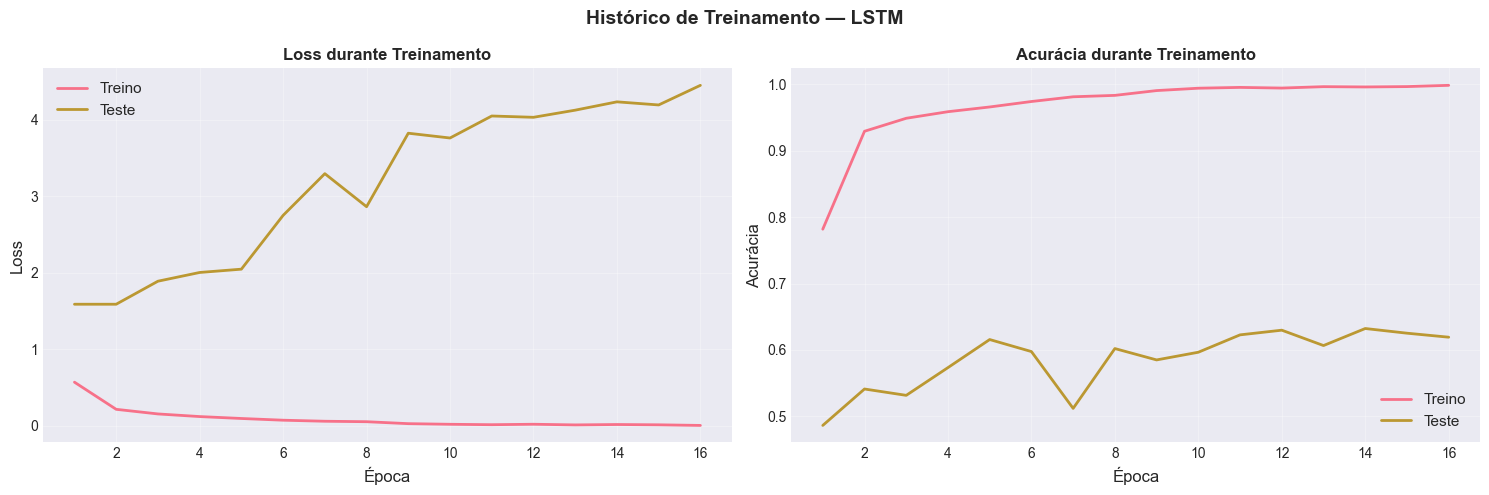


📊 Resumo final:
  Treino — loss: 0.0071  |  acc: 0.9983
  Teste  — loss: 4.4487  |  acc: 0.6192


In [39]:
# Visualizar histórico de treinamento
# Curvas próximas e decrescentes indicam bom aprendizado sem overfitting.
# Um grande gap entre treino e teste indica overfitting.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Histórico de Treinamento — LSTM', fontsize=14, fontweight='bold')

epochs = range(1, len(history.history['loss']) + 1)

axes[0].plot(epochs, history.history['loss'], label='Treino', linewidth=2)
axes[0].plot(epochs, history.history['val_loss'], label='Teste', linewidth=2)
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss durante Treinamento', fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history.history['accuracy'], label='Treino', linewidth=2)
axes[1].plot(epochs, history.history['val_accuracy'], label='Teste', linewidth=2)
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Acurácia', fontsize=12)
axes[1].set_title('Acurácia durante Treinamento', fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Resumo final:")
print(f"  Treino — loss: {history.history['loss'][-1]:.4f}  |  acc: {history.history['accuracy'][-1]:.4f}")
print(f"  Teste  — loss: {history.history['val_loss'][-1]:.4f}  |  acc: {history.history['val_accuracy'][-1]:.4f}")

## 5. Avaliar Desempenho do Modelo

Avaliação no conjunto de **teste** (Rodrigo — sujeito completamente novo):
- **Matriz de confusão**: mostra onde o modelo erra e acerta
- **Acurácia por classe**: identifica classes difíceis de classificar
- **Classification report**: precision, recall e F1 por exercício

Também avaliamos apenas os **exercícios ativos** (excluindo descanso) para medir a capacidade de discriminação entre movimentos sem a classe "fácil".

📊 Resultados no conjunto de TESTE (Rodrigo — nunca visto no treino):
  Accuracy:      0.4864  (treino: 0.9290)
  F1 (weighted): 0.4302  (treino: 0.9290)

              precision    recall  f1-score   support

      flexao       0.37      0.64      0.47       497
 agachamento       0.76      0.06      0.12       497
    descanso       0.52      0.89      0.66       497
rosca_biceps       0.79      0.35      0.48       497

    accuracy                           0.49      1988
   macro avg       0.61      0.49      0.43      1988
weighted avg       0.61      0.49      0.43      1988



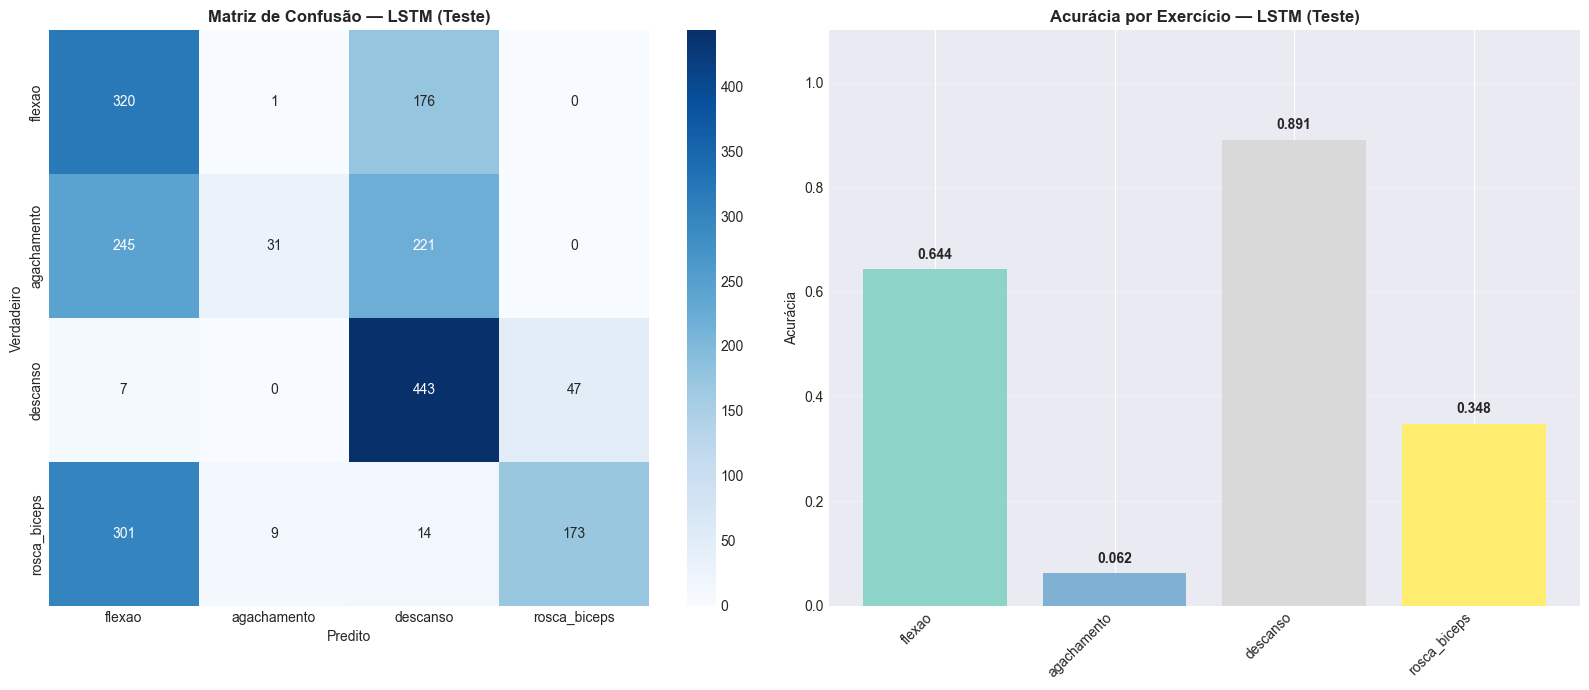

In [40]:
# Predições — o scaler já foi aplicado em X_train_scaled / X_test_scaled
y_train_pred_enc = model.predict(X_train_scaled, verbose=0).argmax(axis=1)
y_test_pred_enc  = model.predict(X_test_scaled,  verbose=0).argmax(axis=1)

# Métricas gerais
train_accuracy = accuracy_score(y_train, y_train_pred_enc)
test_accuracy  = accuracy_score(y_test,  y_test_pred_enc)
train_f1 = f1_score(y_train, y_train_pred_enc, average='weighted')
test_f1  = f1_score(y_test,  y_test_pred_enc,  average='weighted')

target_names = [reverse_label_map[i] for i in sorted(label_map.values())]
cm = confusion_matrix(y_test, y_test_pred_enc, labels=sorted(label_map.values()))

print(f"📊 Resultados no conjunto de TESTE (Rodrigo — nunca visto no treino):")
print(f"  Accuracy:      {test_accuracy:.4f}  (treino: {train_accuracy:.4f})")
print(f"  F1 (weighted): {test_f1:.4f}  (treino: {train_f1:.4f})")
print(f"\n{classification_report(y_test, y_test_pred_enc, target_names=target_names, zero_division=0)}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Matriz de confusão
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True,
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title('Matriz de Confusão — LSTM (Teste)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Verdadeiro')
axes[0].set_xlabel('Predito')

# Acurácia por classe
per_class_totals = cm.sum(axis=1)
with np.errstate(divide='ignore', invalid='ignore'):
    per_class_accuracy = np.where(per_class_totals > 0, cm.diagonal() / per_class_totals, np.nan)
colors_bar = plt.cm.Set3(np.linspace(0, 1, len(target_names)))
axes[1].bar(target_names, [v if not np.isnan(v) else 0 for v in per_class_accuracy], color=colors_bar)
axes[1].set_ylabel('Acurácia')
axes[1].set_title('Acurácia por Exercício — LSTM (Teste)', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1.1])
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(per_class_accuracy):
    label_txt = f'{v:.3f}' if not np.isnan(v) else 'n/a'
    axes[1].text(i, (v if not np.isnan(v) else 0) + 0.02, label_txt, ha='center', fontweight='bold')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

  ACURÁCIA — APENAS EXERCÍCIOS ATIVOS (flexão, agach., rosca)

  Conjunto               Acurácia
  --------------------------------
  Treino                   0.9416
  Teste                    0.3514

  CLASSIFICATION REPORT — TESTE (active)
              precision    recall  f1-score   support

      flexao       0.37      0.64      0.47       497
 agachamento       0.76      0.06      0.12       497
rosca_biceps       1.00      0.35      0.52       497

   micro avg       0.49      0.35      0.41      1491
   macro avg       0.71      0.35      0.37      1491
weighted avg       0.71      0.35      0.37      1491



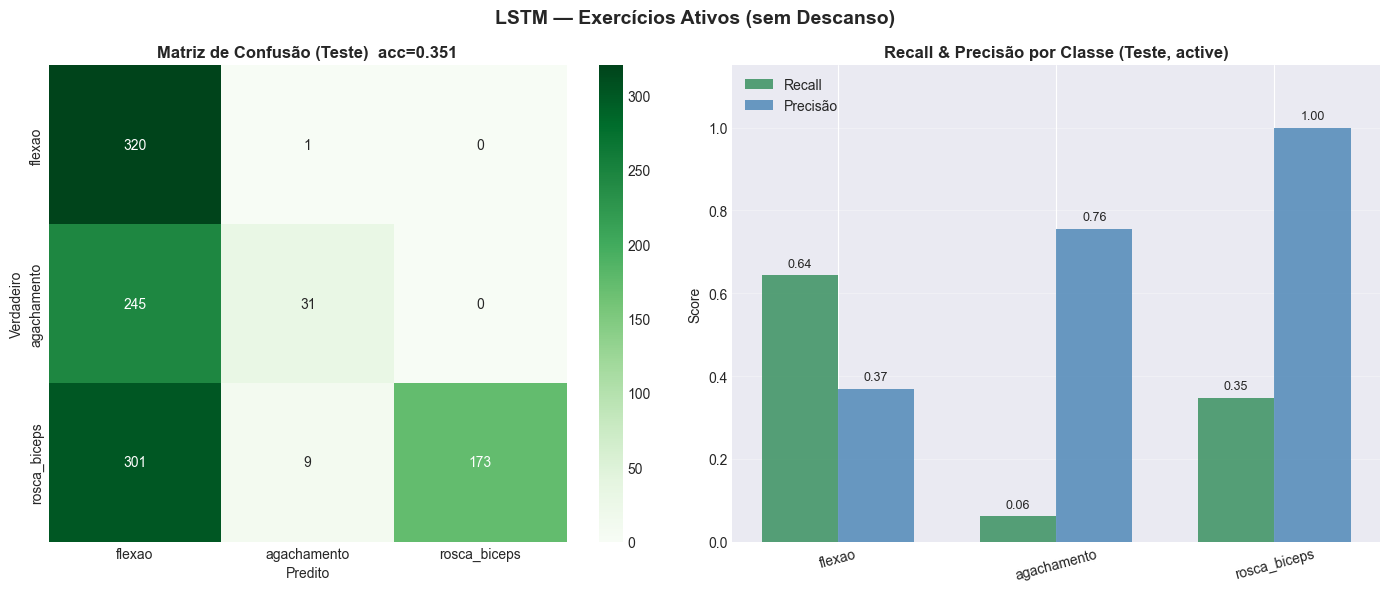

In [41]:
# ── Filtrar apenas exercícios ativos (excluindo descanso) ────────────────────
# O descanso costuma ser trivialmente separável (postura parada), então avaliamos
# a capacidade do modelo de discriminar entre os exercícios de movimento.
active_labels = {k: v for k, v in label_map.items() if k != 'descanso'}
active_label_values = list(active_labels.values())

active_mask_test  = y_test.isin(active_label_values)
active_mask_train = y_train.isin(active_label_values)

y_test_active  = y_test[active_mask_test].reset_index(drop=True)
y_train_active = y_train[active_mask_train].reset_index(drop=True)
y_test_pred_act  = y_test_pred_enc[active_mask_test.values]
y_train_pred_act = y_train_pred_enc[active_mask_train.values]

active_names = [reverse_label_map[i] for i in sorted(active_label_values)]

acc_train_active = accuracy_score(y_train_active, y_train_pred_act)
acc_test_active  = accuracy_score(y_test_active,  y_test_pred_act)

print("=" * 65)
print("  ACURÁCIA — APENAS EXERCÍCIOS ATIVOS (flexão, agach., rosca)")
print("=" * 65)
print(f"\n  {'Conjunto':<12} {'Acurácia':>18}")
print(f"  {'-'*32}")
print(f"  {'Treino':<12} {acc_train_active:>18.4f}")
print(f"  {'Teste':<12} {acc_test_active:>18.4f}")

print(f"\n{'='*65}")
print("  CLASSIFICATION REPORT — TESTE (active)")
print(f"{'='*65}")
print(classification_report(y_test_active, y_test_pred_act,
                             labels=sorted(active_label_values),
                             target_names=active_names, zero_division=0))

# ── Gráfico ──────────────────────────────────────────────────────────────────
cm_active = confusion_matrix(y_test_active, y_test_pred_act,
                             labels=sorted(active_label_values))
report_active = classification_report(y_test_active, y_test_pred_act,
                                      labels=sorted(active_label_values),
                                      target_names=active_names,
                                      output_dict=True, zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('LSTM — Exercícios Ativos (sem Descanso)', fontsize=14, fontweight='bold')

sns.heatmap(cm_active, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=active_names, yticklabels=active_names)
axes[0].set_title(f'Matriz de Confusão (Teste)  acc={acc_test_active:.3f}', fontweight='bold')
axes[0].set_ylabel('Verdadeiro'); axes[0].set_xlabel('Predito')

rec  = [report_active[c]['recall']    for c in active_names]
prec = [report_active[c]['precision'] for c in active_names]
x = np.arange(len(active_names))
w = 0.35
axes[1].bar(x - w/2, rec,  w, label='Recall',   color='seagreen',  alpha=0.8)
axes[1].bar(x + w/2, prec, w, label='Precisão', color='steelblue', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(active_names, rotation=15)
axes[1].set_ylim([0, 1.15]); axes[1].set_ylabel('Score')
axes[1].set_title('Recall & Precisão por Classe (Teste, active)', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for i, (r, p) in enumerate(zip(rec, prec)):
    axes[1].text(i - w/2, r + 0.02, f'{r:.2f}', ha='center', fontsize=9)
    axes[1].text(i + w/2, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [42]:
# ── Salvar artefatos do modelo LSTM ──────────────────────────────────────────
# Salvamos 3 artefatos necessários para inferência em novos vídeos:
#   1. Modelo LSTM completo (arquitetura + pesos)
#   2. Scaler (para normalizar novas janelas com as mesmas estatísticas do treino)
#   3. Label map (para converter predição numérica de volta ao nome do exercício)

print("💾 Salvando artefatos...\n")

# Modelo Keras (.keras é o formato recomendado pós-TF 2.12)
lstm_model_path = ML_MODELS_DIR / "lstm_4exercises_model.keras"
model.save(lstm_model_path)
model_size = lstm_model_path.stat().st_size / 1024
print(f"  ✓ Modelo LSTM:   {lstm_model_path} ({model_size:.1f} KB)")

# Scaler — necessário para normalizar novas janelas na inferência
scaler_path = ML_MODELS_DIR / "lstm_4exercises_scaler.pkl"
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
scaler_size = scaler_path.stat().st_size / 1024
print(f"  ✓ Scaler:        {scaler_path} ({scaler_size:.1f} KB)")

# Label map — necessário para reverter predição numérica para nome do exercício
label_map_path = ML_MODELS_DIR / "lstm_4exercises_label_map.pkl"
with open(label_map_path, 'wb') as f:
    pickle.dump(label_map, f)
print(f"  ✓ Label Map:     {label_map_path}")

print(f"\n📐 Configurações de inferência:")
print(f"  Window size:  {window_size} frames")
print(f"  N. ângulos:   {n_features}")
print(f"  N. classes:   {n_classes}")
print(f"\n💡 Passos para inferência em novos dados:")
print(f"  1. Extrair janela de {window_size} frames → shape ({window_size}, {n_features})")
print(f"  2. Reshape para (1, {window_size * n_features}) → scaler.transform → reshape (1, {window_size}, {n_features})")
print(f"  3. pred = model.predict(window_scaled).argmax()  →  reverse_label_map[pred]")

💾 Salvando artefatos...

  ✓ Modelo LSTM:   ml_models\lstm_4exercises_model.keras (434.2 KB)
  ✓ Scaler:        ml_models\lstm_4exercises_scaler.pkl (0.6 KB)
  ✓ Label Map:     ml_models\lstm_4exercises_label_map.pkl

📐 Configurações de inferência:
  Window size:  15 frames
  N. ângulos:   10
  N. classes:   4

💡 Passos para inferência em novos dados:
  1. Extrair janela de 15 frames → shape (15, 10)
  2. Reshape para (1, 150) → scaler.transform → reshape (1, 15, 10)
  3. pred = model.predict(window_scaled).argmax()  →  reverse_label_map[pred]


## 9. 💡 Sugestões de Melhorias

### Arquitetura
| Sugestão | Por que pode ajudar |
|---|---|
| **Bidirectional LSTM** | Processa a sequência em ambas as direções — útil pois frames futuros também contêm contexto para classificar o exercício atual (`Bidirectional(LSTM(64))`) |
| **1D CNN + LSTM** | CNN extrai padrões locais de ativação (3–5 frames), LSTM captura dinâmica de longo prazo — `Conv1D → MaxPooling1D → LSTM` |
| **Self-Attention / Transformer Encoder** | Aprende quais frames da janela são mais relevantes sem depender de recorrência — geralmente supera LSTM em séries temporais |
| **GRU** | Equivalente à LSTM com menos parâmetros — treina mais rápido com performance comparável |

### Features
| Sugestão | Por que pode ajudar |
|---|---|
| **Combinar ângulos + velocidade angular (Δangles)** | Ângulos descrevem postura; deltas descrevem dinâmica — juntos formam representação mais completa (`n_features = 8 + 8 + 2 = 18`) |
| **Assimetria L/R** | `right_angle − left_angle` por articulação captura desequilíbrios posturais específicos de cada exercício |
| **Energia do movimento** | `sqrt(Σ Δangle²)` por frame — resume a intensidade do movimento naquele instante |

### Dados e Treinamento
| Sugestão | Por que pode ajudar |
|---|---|
| **Aumentar `window_size` para 30** | Captura ciclos completos de movimentos mais lentos (agachamento ~6 s a 5 fps) |
| **Data augmentation** | Ruído gaussiano nos ângulos (`σ ≈ 1°`) ou time-stretch simulado aumenta robustez a variações individuais |
| **Label smoothing** | `CategoricalCrossentropy(label_smoothing=0.1)` — reduz overconfidence e melhora generalização |
| **LSTM Stateful** | Processa vídeos inteiros frame a frame mantendo estado oculto — elimina windowing e permite inferência online em tempo real |